# UNIVERSIDAD PERUANA DE CIENCIAS APLICADAS – UPC  
## CARRERA PROFESIONAL: CIENCIAS DE LA COMPUTACIÓN  
### PRÁCTICA CALIFICADA 02  
### Curso: Data Mining Tools  
### Docente: Ph.D. Carlos Fernando Montoya Cubas  
### Semestre: 2025-02  
### Duración: 200 minutos  
### Modalidad: Grupal  
### Total: 20 puntos  

---

## PRÁCTICA CALIFICADA 02 – Clustering y Selección de Características  

**Indicaciones generales:**  
- Trabajo en equipos según indicaciones del docente.  
- Completar todas las secciones en este notebook.  
- Justificar siempre sus decisiones (selección de métodos, parámetros, etc.).  
- Usar gráficos y tablas cuando sea pertinente.  
- Comentar el código para facilitar la lectura.


---
# PARTE A – CLUSTERING (10 puntos)

**Dataset requerido (Clustering): Customer Personality Analysis (Kaggle)**  
Incluye valores faltantes y variables mixtas.  

**Enlace directo al dataset:**  
 https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis  



## Pregunta A1 (5 puntos): Preprocesamiento, imputación y preparación de datos

**Objetivo:** Realizar una limpieza y preparación adecuada del dataset antes de aplicar algoritmos de clustering.

### Tareas obligatorias

1. **Auditoría de datos:**
   - Calcular el porcentaje de valores faltantes por columna.
   - Identificar variables numéricas y categóricas.
   - Detectar posibles *outliers* en las variables numéricas (breve análisis descriptivo o gráfico).

2. **Imputación comparada de valores faltantes:**
   - Aplicar `SimpleImputer` (media o mediana según corresponda).
   - Aplicar `KNNImputer`.
   - Comparar los resultados y comentar cuál método consideras más adecuado para este dataset y por qué.

3. **Escalamiento comparado:**
   - Probar `StandardScaler`.
   - Probar `MinMaxScaler`.
   - Comentar brevemente las diferencias observadas en la distribución de los datos.

4. **Codificación de variables categóricas:**
   - Aplicar One Hot Encoding a las variables categóricas seleccionadas.

### Entregables A1

- Tablas o resúmenes antes y después de la imputación.
- Breve comparación escrita entre los métodos de imputación y de escalamiento elegidos.
- Explicación clara y concisa de las decisiones tomadas.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### A1.1 Carga del dataset y auditoría inicial

In [245]:
# A1.1 Carga del dataset y exploración inicial
import pandas as pd
import kagglehub

# Ejemplo: df = pd.read_csv('marketing_campaign.csv')
# Reemplaza con la ruta real del archivo descargado desde Kaggle
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
df = pd.read_csv(path + '/marketing_campaign.csv', sep='\t')


In [246]:
# Mostrar información general
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### A1.2 Imputación de valores faltantes (SimpleImputer vs KNNImputer)

In [247]:
# A1.2 Imputación de valores faltantes
from sklearn.impute import SimpleImputer, KNNImputer

# Separar variables numéricas y categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('ID')
num_cols = num_cols.drop('Z_CostContact')
num_cols = num_cols.drop('Z_Revenue')

cat_cols = df.select_dtypes(include=['object']).columns

df_simple = df.copy()
df_knn = df.copy()

# Implementar aquí los dos esquemas de imputación y comparar

# Imputación simple
simple_imputer = SimpleImputer(strategy='mean')
df_simple[num_cols] = simple_imputer.fit_transform(df_simple[num_cols])


# Imputación KNN
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])

comparacion = pd.DataFrame({
    "Media Original": df[num_cols].mean(),
    "Media con Imp Simple": df_simple[num_cols].mean(),
    "Media con Imp KNN": df_knn[num_cols].mean()
})

print(comparacion)


                     Media Original  Media con Imp Simple  Media con Imp KNN
Year_Birth              1968.805804           1968.805804        1968.805804
Income                 52247.251354          52247.251354       52224.992589
Kidhome                    0.444196              0.444196           0.444196
Teenhome                   0.506250              0.506250           0.506250
Recency                   49.109375             49.109375          49.109375
MntWines                 303.935714            303.935714         303.935714
MntFruits                 26.302232             26.302232          26.302232
MntMeatProducts          166.950000            166.950000         166.950000
MntFishProducts           37.525446             37.525446          37.525446
MntSweetProducts          27.062946             27.062946          27.062946
MntGoldProds              44.021875             44.021875          44.021875
NumDealsPurchases          2.325000              2.325000           2.325000

## INTERPRETACION (antes y despues de la imputacion):
La unica columna donde se encontraban valores faltantes fue "Income", en los resultados se aprecia que con una imputacion simple la media no cambia, mientras que con una imputacion con KNN la diferencia con la media original es 22.258765. No hay mucha diferencia teniendo en cuenta que el rango de valores de esta variable es mucho mayor al valor obtenido.

In [248]:
#Se usara el de imputacion simple para los siguientes pasos
df[num_cols] = simple_imputer.fit_transform(df[num_cols]) 

### A1.3 Escalamiento (StandardScaler vs MinMaxScaler)

In [249]:
# A1.3 Aplicar y comparar StandardScaler y MinMaxScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

# Aplicar escalamiento a las columnas numéricas seleccionadas

df_std = df.copy()
df_mm = df.copy()

df_std[num_cols] = scaler_std.fit_transform(df_std[num_cols])
df_mm[num_cols] = scaler_mm.fit_transform(df_mm[num_cols])



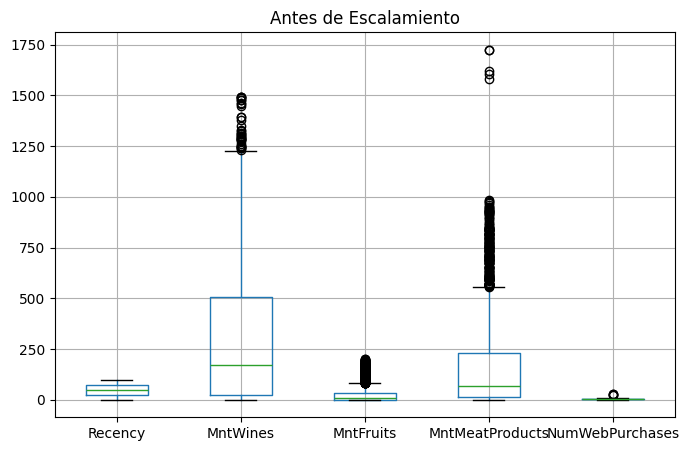

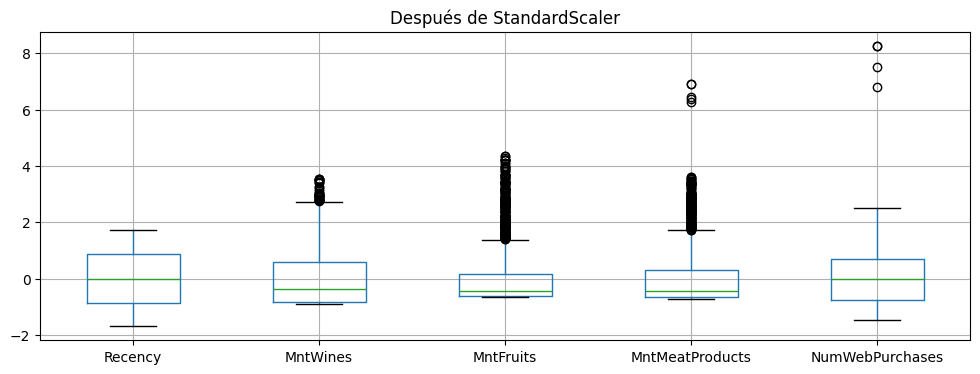

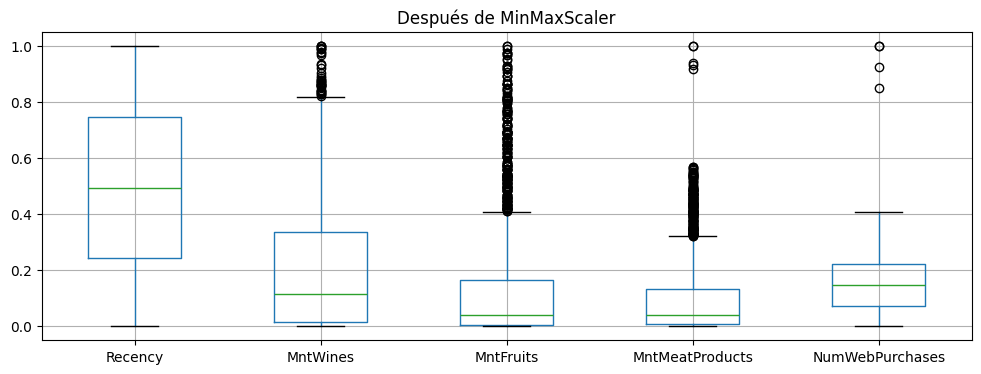

In [250]:
import matplotlib.pyplot as plt
#SIN INCOME
columnas_seleccionas = ['Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'NumWebPurchases']

df[columnas_seleccionas].boxplot(figsize=(12,4))
plt.title("Antes de Escalamiento")
plt.show()

df_std[columnas_seleccionas].boxplot(figsize=(12,4))
plt.title("Después de StandardScaler")
plt.show()

df_mm[columnas_seleccionas].boxplot(figsize=(12,4))
plt.title("Después de MinMaxScaler")
plt.show()

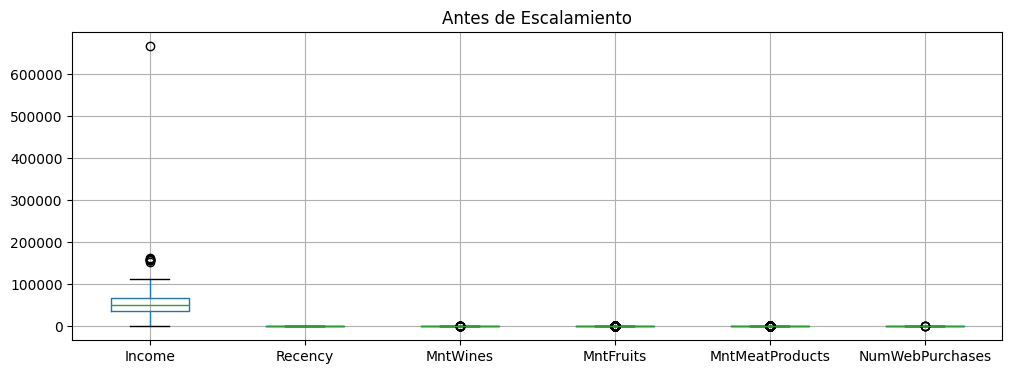

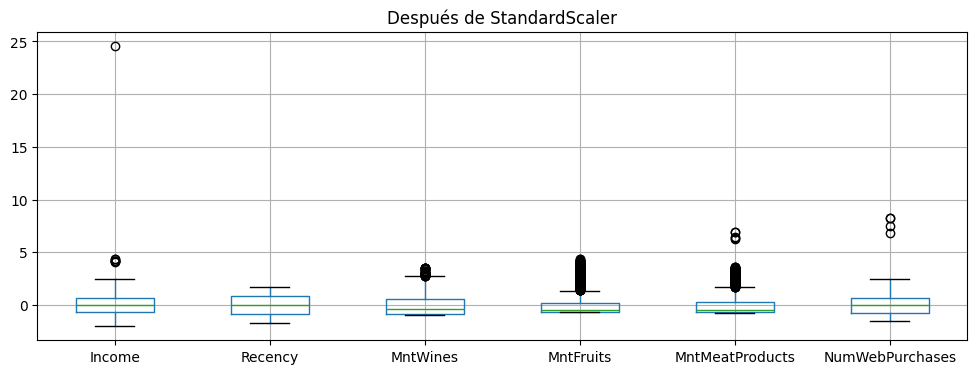

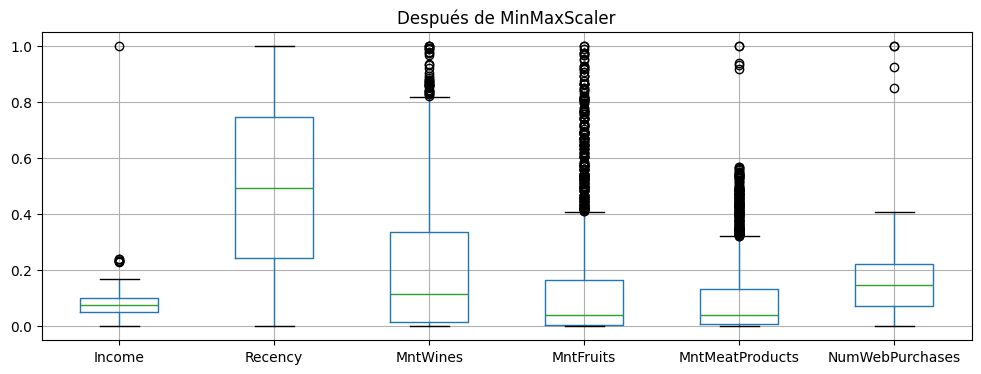

In [251]:
import matplotlib.pyplot as plt
#CON INCOME
columnas_seleccionas = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'NumWebPurchases']

df[columnas_seleccionas].boxplot(figsize=(12,4))
plt.title("Antes de Escalamiento")
plt.show()

df_std[columnas_seleccionas].boxplot(figsize=(12,4))
plt.title("Después de StandardScaler")
plt.show()

df_mm[columnas_seleccionas].boxplot(figsize=(12,4))
plt.title("Después de MinMaxScaler")
plt.show()

## INTERPRETACION

**ANTES DEL ESCALAMIENTO:**

Se observa que las variables tenian escalas muy diferentes. Por ejemplo, Income tenía valores grandes mientras que otras variables como compras o visitas tenian valores pequeños. Entonces, si no se normaliza, algunos modelos (como KNN o redes neuronales) le daran mas peso a ciertas variables solo por su escala. 

**DESPUES DE StandardScaler:**

Cuando se aplicó StandardScaler, todas las variables quedaron centradas alrededor de 0 y con desviacion estandar cercana a 1. Lo interesante es que la forma del boxplot casi no cambia, es decir, mantiene la distribución original y los outliers siguen ahí (Primeros 3 graficos). Este método es útil cuando se usa algo como regresión logística, SVM o PCA porque estos modelos asumen datos más o menos distribuidos.

**DESPUES DE MinMaxScaler:**

Con MinMaxScaler todo quedó en el rango de 0 a 1. La escala quedó mucho más uniforme. Este método se recomienda cuando el modelo depende de distancias, como KNN o redes neuronales.

In [252]:
print("Estadísticas después de StandardScaler:")
df_std[num_cols].describe().round(3)

Estadísticas después de StandardScaler:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,...,2240.000,2240.000,2240.000,2240.00,2240.000,2240.00,2240.000,2240.000,2240.000,2240.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,...,0.000,0.000,-0.000,-0.00,0.000,-0.00,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.00,1.000,1.00,1.000,1.000,1.000,1.000
min,-6.327,-2.018,-0.825,-0.930,-1.696,-0.903,-0.661,-0.740,-0.687,-0.656,...,-0.911,-1.781,-2.191,-0.28,-0.284,-0.28,-0.262,-0.117,-0.097,-0.419
25%,-0.818,-0.667,-0.825,-0.930,-0.867,-0.833,-0.636,-0.669,-0.632,-0.632,...,-0.911,-0.858,-0.955,-0.28,-0.284,-0.28,-0.262,-0.117,-0.097,-0.419
50%,0.100,-0.020,-0.825,-0.930,-0.004,-0.388,-0.460,-0.443,-0.467,-0.462,...,-0.227,-0.243,0.282,-0.28,-0.284,-0.28,-0.262,-0.117,-0.097,-0.419
75%,0.684,0.641,1.033,0.907,0.860,0.595,0.168,0.288,0.228,0.144,...,0.458,0.680,0.694,-0.28,-0.284,-0.28,-0.262,-0.117,-0.097,-0.419
max,2.270,24.545,2.890,2.744,1.723,3.533,4.343,6.904,4.055,5.717,...,8.670,2.218,6.052,3.57,3.523,3.57,3.815,8.583,10.279,2.389


In [253]:
print("Estadísticas después de MinMaxScaler:")
df_mm[num_cols].describe().round(3)

Estadísticas después de MinMaxScaler:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,...,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000
mean,0.736,0.076,0.222,0.253,0.496,0.204,0.132,0.097,0.145,0.103,...,0.095,0.445,0.266,0.073,0.075,0.073,0.064,0.013,0.009,0.149
std,0.116,0.038,0.269,0.272,0.293,0.225,0.200,0.131,0.211,0.157,...,0.104,0.250,0.121,0.260,0.263,0.260,0.245,0.115,0.096,0.356
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.641,0.051,0.000,0.000,0.242,0.016,0.005,0.009,0.012,0.004,...,0.000,0.231,0.150,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.748,0.075,0.000,0.000,0.495,0.116,0.040,0.039,0.046,0.030,...,0.071,0.385,0.300,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.816,0.100,0.500,0.500,0.747,0.338,0.166,0.134,0.193,0.125,...,0.143,0.615,0.350,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [254]:
# Se usara StandardScaler para los siguientes pasos
df[num_cols] = scaler_std.fit_transform(df[num_cols])

### A1.4 Codificación de categóricas (One Hot Encoding)

In [255]:
# A1.4 One Hot Encoding
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Usar pd.get_dummies o OneHotEncoder según prefieras

cat_cols = df.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

df = pd.concat([df.drop(cat_cols, axis=1).reset_index(drop=True), encoded_df], axis=1)

df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Dt_Customer_31-03-2014,Dt_Customer_31-05-2013,Dt_Customer_31-05-2014,Dt_Customer_31-07-2012,Dt_Customer_31-07-2013,Dt_Customer_31-08-2012,Dt_Customer_31-08-2013,Dt_Customer_31-10-2012,Dt_Customer_31-12-2012,Dt_Customer_31-12-2013
0,5524,-0.985345,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2174,-1.235733,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4141,-0.317643,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6182,1.268149,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5324,1.017761,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### A1.5 Conclusiones de preprocesamiento
Escribe aquí tus conclusiones sobre:
- Método de imputación elegido y por qué.
- Tipo de escalamiento seleccionado y su justificación.
- Impacto general del preprocesamiento sobre los datos.

### SimpleImputer

Para el preprocesamiento de los datos se eligió SimpleImputer (por media, datos numericos) porque no modifica demasiado la distribución original de las variables. Además, los datos no presentaban un porcentaje alto de valores nulos. Entonces, una imputación simple resultaba suficiente.


### StandardScaler

En cuanto al escalamiento, se seleccionó StandardScaler porque mantiene la forma y distribución de los datos al estandarizarlos alrededor de una media de 0 y desviación estándar de 1. A diferencia de MinMaxScaler, StandardScaler conserva mejor la variabilidad y no comprime tanto los valores extremos.

### Impacto General

En general, después del preprocesamiento los datos quedaron más limpios, completos y en una escala comparable. Esto debería ayudar a que los modelos posteriores funcionen mejor y no se vean afectados por diferencias de magnitud o datos faltantes.

---
## Pregunta A2 (5 puntos): Clustering usando K-Means, EM (GMM), DBSCAN y Jerárquico

**Objetivo:** Aplicar distintos algoritmos de clustering y comparar su desempeño sobre el dataset preprocesado.

### Tareas obligatorias

1. **Selección del número de clusters (cuando aplique):**
   - Utilizar *Elbow Method* para sugerir un rango de posibles números de clusters.
   - Calcular el *Silhouette Score* para distintos valores de k y elegir un número adecuado de clusters.

2. **Aplicar los 4 algoritmos de clustering:**
   - K-Means++
   - Gaussian Mixture Models (EM/GMM)
   - DBSCAN
   - Clustering Jerárquico (método de enlace Ward)

3. **Evaluación y comparación:**
   - Calcular para cada modelo (cuando corresponda):
     - Silhouette Score
     - Davies–Bouldin Index
   - Proyectar los datos a 2 dimensiones usando PCA y graficar los clusters para cada algoritmo.

4. **Análisis:**
   - Discutir qué algoritmo produce agrupamientos más coherentes para este problema.
   - Indicar si DBSCAN detecta ruido (*outliers*) de manera razonable.
   - Comentar brevemente diferencias entre clusters esféricos (K-Means), elípticos (GMM) y arbitrarios (DBSCAN).

### Entregables A2

- Gráficos de *Elbow* y *Silhouette*.
- Gráficos de clusters en 2D (PCA) para cada algoritmo.
- Tabla comparativa de métricas internas.
- Conclusión técnica argumentada.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### A2.1 Selección del número de clusters (Elbow & Silhouette)

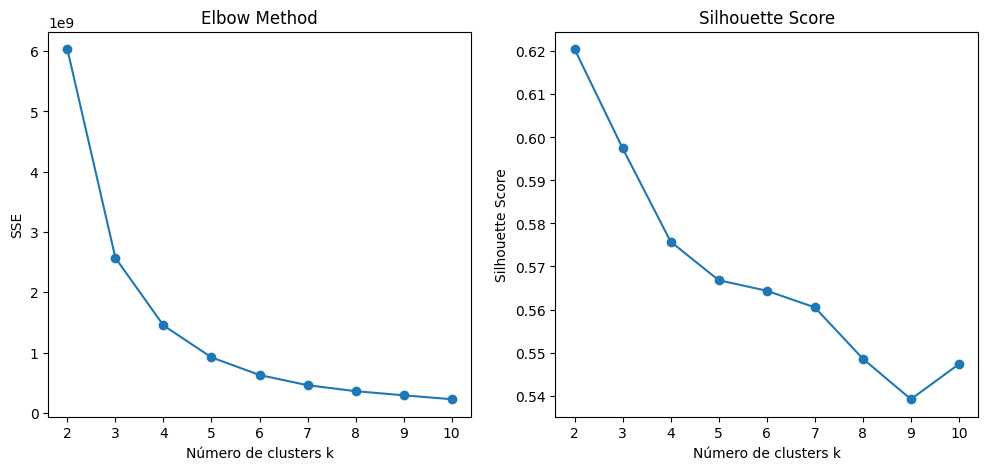

In [256]:
# A2.1 Cálculo de Elbow y Silhouette para K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Implementar aquí el barrido de k y los gráficos
sse = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df, labels))

# Gráfico de Elbow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Número de clusters k')
plt.ylabel('SSE')



# Gráfico de Silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')

plt.show()

### A2.2 Aplicación de K-Means, GMM, DBSCAN y Jerárquico

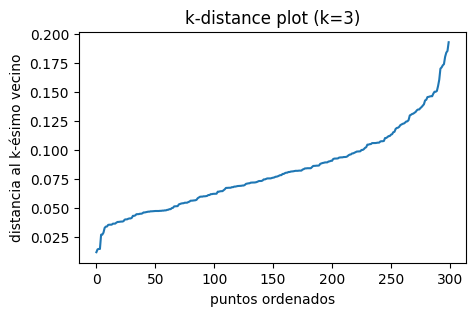

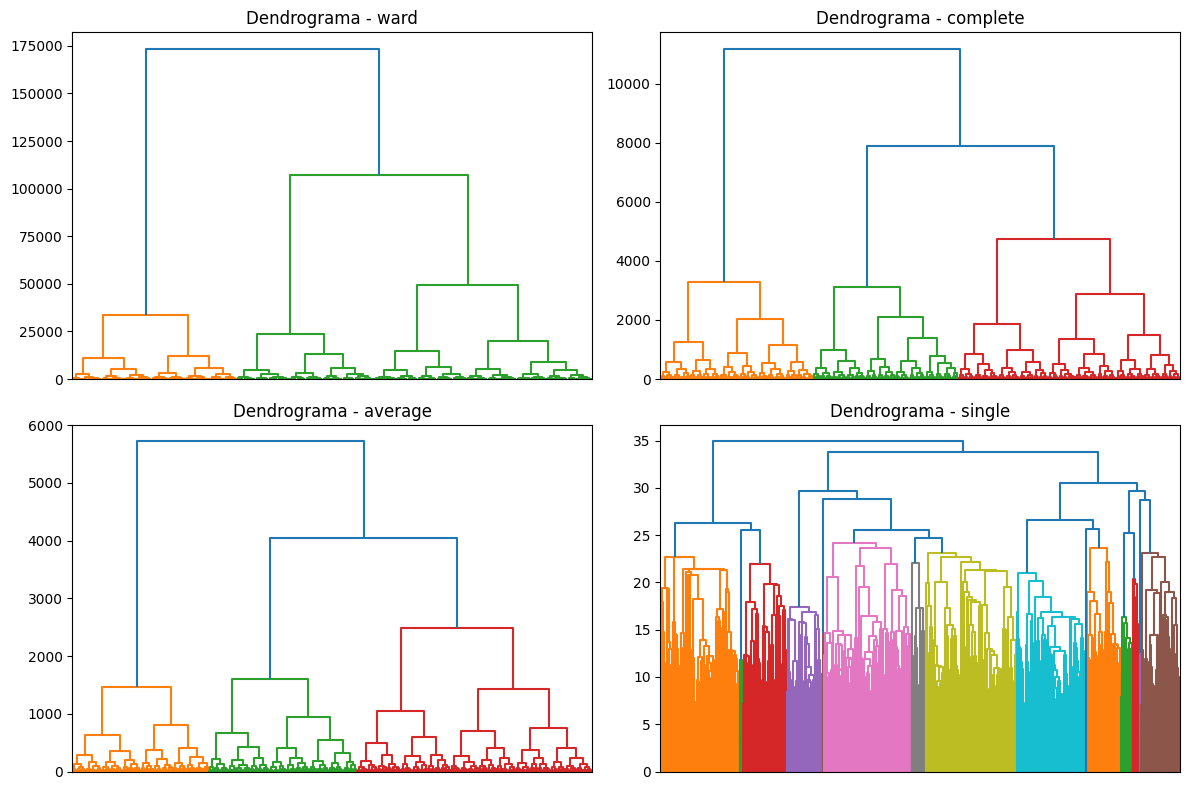

In [257]:
# A2.2 Clustering con los 4 algoritmos
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# Ajustar aquí los modelos usando los datos preprocesados
k = 3  # Número de clusters basado en análisis previo

# K-Means
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(df)

# Gaussian Mixture Models
gmm = GaussianMixture(n_components=k, random_state=42)
gmm_labels = gmm.fit_predict(df)

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=3)
dbscan_labels = dbscan.fit_predict(df)

X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

pca_moons = PCA(n_components=2)
X_moons_2d = pca_moons.fit_transform(X_moons_scaled)

def k_distance_plot(X, k=4):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    kth_dist = np.sort(dists[:, -1])
    plt.figure(figsize=(5,3))
    plt.plot(kth_dist)
    plt.title(f"k-distance plot (k={k})")
    plt.xlabel("puntos ordenados")
    plt.ylabel("distancia al k-ésimo vecino")
    plt.show()

k_distance_plot(X_moons_scaled, k)


# Clustering Jerárquico
linkage_methods = ["ward", "complete", "average", "single"]
linkages = {}

for m in linkage_methods:
    Z = linkage(df, method=m)
    linkages[m] = Z

plt.figure(figsize=(12,8))

for i, m in enumerate(linkage_methods, start=1):
    plt.subplot(2,2,i)
    dendrogram(linkages[m], no_labels=True)
    plt.title(f"Dendrograma - {m}")

plt.tight_layout()
plt.show()

labels_hierarchical = {}
for m in linkage_methods:
    Z = linkages[m]
    hierarchical_labels = fcluster(linkages["ward"], t=k, criterion='maxclust')
    labels_hierarchical[m] = hierarchical_labels

In [258]:
# Ajustamos DBSCAN
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(df)

### A2.3 Visualización en 2D con PCA

<Figure size 1200x1000 with 0 Axes>

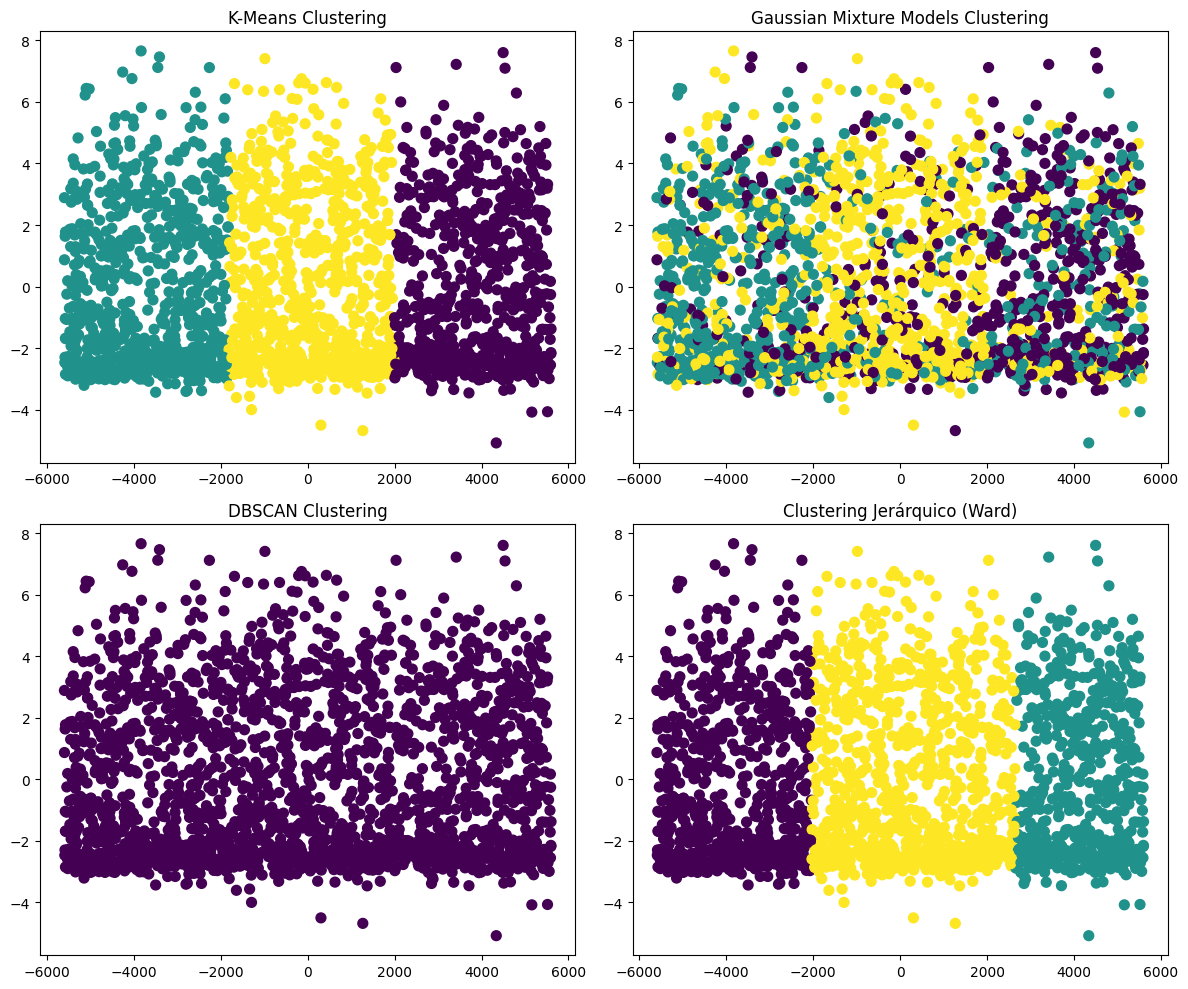

In [259]:
# A2.3 PCA y gráficos de clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Implementar PCA y graficar los resultados para cada algoritmo
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)
plt.figure(figsize=(12, 10))
plt.figure(figsize=(12, 10))

# K-Means
plt.subplot(2, 2, 1)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title('K-Means Clustering')


# Gaussian Mixture Models
plt.subplot(2, 2, 2)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=gmm_labels, cmap='viridis', s=50)
plt.title('Gaussian Mixture Models Clustering')

# DBSCAN
plt.subplot(2, 2, 3)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN Clustering')

# Clustering Jerárquico (usando 'ward')
plt.subplot(2, 2, 4)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_hierarchical['ward'], cmap='viridis', s=50)
plt.title('Clustering Jerárquico (Ward)')

plt.tight_layout()
plt.show()


In [260]:
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(df)
print("Etiquetas encontradas:", np.unique(dbscan_labels))

Etiquetas encontradas: [-1]


### A2.4 Cálculo de métricas y comparación

In [261]:
# A2.4 Cálculo de Silhouette y Davies–Bouldin para cada algoritmo
from sklearn.metrics import davies_bouldin_score

# Calcular métricas y organizarlas en una tabla
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

def safe_silhouette_score(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan
    return silhouette_score(X, labels)

def safe_davies_bouldin_score(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan
    return davies_bouldin_score(X, labels)

metrics = {
    'K-Means': {
        'Silhouette': safe_silhouette_score(df, kmeans_labels),
        'Davies-Bouldin': safe_davies_bouldin_score(df, kmeans_labels)
    },
    'Gaussian Mixture': {
        'Silhouette': safe_silhouette_score(df, gmm_labels),
        'Davies-Bouldin': safe_davies_bouldin_score(df, gmm_labels)
    },
    'DBSCAN': {
        'Silhouette': safe_silhouette_score(df, dbscan_labels),
        'Davies-Bouldin': safe_davies_bouldin_score(df, dbscan_labels)
    },
    'Hierarchical (Ward)': {
        'Silhouette': safe_silhouette_score(df, labels_hierarchical['ward']),
        'Davies-Bouldin': safe_davies_bouldin_score(df, labels_hierarchical['ward'])
    }
}

comparison_df = pd.DataFrame(metrics).T
print("Comparación de métricas de clustering:")
print(comparison_df)

Comparación de métricas de clustering:
                     Silhouette  Davies-Bouldin
K-Means                0.597458        0.495587
Gaussian Mixture       0.008209        3.903538
DBSCAN                      NaN             NaN
Hierarchical (Ward)    0.579742        0.494860


### A2.5 Conclusiones sobre los algoritmos de clustering
Escribe aquí tus conclusiones comparando K-Means, GMM, DBSCAN y Jerárquico en términos de:
- Calidad de clusters (métricas).
- Capacidad de detectar ruido.
- Interpretabilidad de los resultados.


- EK-Means y Clustering jerárquico demostraron una calidad de agrupamiento superior, con Silhouette Scores de 0.597 y 0.580 respectivamente, indicando una estructura de clusters bien definida. Los valores de Davies-Bouldin (0.495-0.494) confirman una excelente separación y compactación entre grupos. Los dendrogramas revelan que el método Ward proporciona la estructura más coherente, respaldando las métricas numéricas obtenidas.

- DBSCAN no logró formar clusters válidos (valores NaN), sugiriendo que la densidad de los datos no se ajusta a los supuestos del algoritmo. El gráfico k-distance con k=3 no muestra un "codo" definido, indicando dificultades para encontrar parámetros óptimos. Gaussian Mixture presentó un desempeño muy pobre, con métricas que reflejan incapacidad para identificar patrones claros en la estructura de los datos.

- K-Means emerge como la solución más efectiva, combinando las mejores métricas con alta interpretabilidad visual mediante clusters bien definidos. El Clustering Jerárquico con Ward representa otra alternativa sólida, ofreciendo similar calidad métrica junto con la ventaja adicional de ser respaldada por los dendrogramas que analizaron sus relaciones jerárquicas.

---
# PARTE B – SELECCIÓN DE CARACTERÍSTICAS (10 puntos)

**Dataset requerido (Selección de Características): Stroke Prediction Dataset (Kaggle)**  
Incluye valores faltantes, variables mixtas y desbalance de clases.

**Enlace directo al dataset:**  
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  

---


## Pregunta B1 (5 puntos): Preprocesamiento, imputación y selección preliminar

**Objetivo:** Preparar el dataset para modelos supervisados y realizar una primera selección de características basada en métodos filtro.

### Tareas

1. **Reporte de valores faltantes:**
   - Mostrar una tabla con el porcentaje de NA por columna.
   - Visualizar con un heatmap (opcional).

2. **Imputación comparada:**
   - Aplicar `SimpleImputer`.
   - Aplicar `IterativeImputer` (MICE).
   - Comparar brevemente ambos métodos y justificar cuál decides usar en el resto de la práctica.

3. **Análisis de correlación:**
   - Calcular matriz de correlación entre variables numéricas.
   - Identificar características redundantes (correlación |r| > 0.8) y proponer cuáles podrían eliminarse.

4. **Codificación categórica:**
   - Aplicar One Hot Encoding a las variables categóricas.

5. **Métodos filtro de selección de características:**
   - Aplicar ANOVA F-test o Chi-cuadrado (según tipo de variable objetivo).
   - Aplicar Mutual Information.
   - Comparar los rankings obtenidos y comentar similitudes/diferencias.

### Entregables B1

- Resumen de NA e imputación.
- Matriz de correlación y variables redundantes.
- Ranking de características según métodos filtro.
- Justificación del conjunto preliminar de características seleccionadas.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### B1.1 Carga del dataset y análisis de valores faltantes

In [262]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
path += "/healthcare-dataset-stroke-data.csv"

In [263]:
import pandas as pd


df = pd.read_csv(path)

df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [264]:
import pandas as pd

# B1.1 Cargar dataset de Stroke Prediction
df_stroke = pd.read_csv(path)
df_stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [265]:
for column in df_stroke.columns:
    if df_stroke[column].nunique() < 10:
        print(f"{column}: {df_stroke[column].unique()}")
    else:
        print(f"{column}: {df_stroke[column].nunique()} valores únicos.")

id: 5110 valores únicos.
gender: ['Male' 'Female' 'Other']
age: 104 valores únicos.
hypertension: [0 1]
heart_disease: [1 0]
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type: ['Urban' 'Rural']
avg_glucose_level: 3979 valores únicos.
bmi: 418 valores únicos.
smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
stroke: [1 0]


In [266]:
df_stroke["gender"] = df_stroke["gender"].replace("Other", None)
df_stroke["smoking_status"] = df_stroke["smoking_status"].replace("Unknown", None)

In [267]:
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     3566 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [268]:
df_stroke.isna().sum() / len(df_stroke)

id                   0.000000
gender               0.000196
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  0.039335
smoking_status       0.302153
stroke               0.000000
dtype: float64

### B1.4 One Hot Encoding y preparación de X, y

In [269]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [270]:
variables_booleanas = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type']
variables_categoricas = ['work_type', 'smoking_status']
variables_numericas = ['age', 'avg_glucose_level', 'bmi']

In [271]:
X = df_stroke.drop(columns=['id', 'stroke'])
y = df_stroke['stroke']

In [272]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=111, stratify=y
)

### B1.2 Imputación (SimpleImputer vs IterativeImputer)

In [273]:
# B1.2 Imputación de valores faltantes
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, IterativeImputer

numeric_simple = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

boolean_simple = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor_simple = ColumnTransformer([
    ('num', numeric_simple, variables_numericas),
    ('cat', categorical_simple, variables_categoricas),
    ('bool', boolean_simple, variables_booleanas)
])

In [274]:
numeric_iter = Pipeline([
    ('imputer', IterativeImputer(random_state=111)),
    ('scaler', StandardScaler())
])

categorical_iter = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

boolean_iter = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor_iter = ColumnTransformer([
    ('num', numeric_iter, variables_numericas),
    ('cat', categorical_iter, variables_categoricas),
    ('bool', boolean_iter, variables_booleanas)
])

In [275]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [276]:
rf_simple = Pipeline([
    ('preprocess', preprocessor_simple),
    ('rf', RandomForestClassifier(random_state=111))
])

rf_iterative = Pipeline([
    ('preprocess', preprocessor_iter),
    ('rf', RandomForestClassifier(random_state=111))
])

In [277]:
rf_simple.fit(X_train, y_train)
rf_iterative.fit(X_train, y_train)

y_pred_simple = rf_simple.predict(X_test)
y_pred_iter = rf_iterative.predict(X_test)

y_prob_simple = rf_simple.predict_proba(X_test)[:, 1]
y_prob_iter = rf_iterative.predict_proba(X_test)[:, 1]

In [278]:
def metricas(y_test, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

In [279]:
metricas_simple = metricas(y_test, y_pred_simple, y_prob_simple)
metricas_iter = metricas(y_test, y_pred_iter, y_prob_iter)

In [280]:
df_metrics = pd.DataFrame({
    'SimpleImputer': metricas_simple,
    'IterativeImputer': metricas_iter
})

df_metrics

,SimpleImputer,IterativeImputer
Accuracy,0.947815,0.949772
Precision,0.000000,0.250000
Recall,0.000000,0.013333
F1-score,0.000000,0.025316
ROC-AUC,0.801372,0.777375


Dado que el dataset está enfocado en predecir la ocurrencia de un accidente cerebrovascular, la métrica más relevante es el recall, ya que en un contexto clínico, es importante minimizar los falsos negativos.

En la evaluación simple, el modelo con `IterativeImputer` obtuvo un recall mayor (0.0133) que el modelo con `SimpleImputer` (0.0000).

Aunque la mejora es mínima debido al fuerte desbalance de clases, sigue indicando que `IterativeImputer` permite recuperar ligeramente más casos positivos que `SimpleImputer`, lo cual es relevante en este escenario médico.

Por este motivo se selecciona `IterativeImputer` como el método de imputación para el resto de la práctica.

### B1.3 Correlación y variables redundantes

In [281]:
# B1.3 Matriz de correlación y detección de alta correlación
import seaborn as sns
import matplotlib.pyplot as plt

data_tr = preprocessor_iter.fit_transform(X)

encoded_cat = preprocessor_iter.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(variables_categoricas)
encoded_bool = preprocessor_iter.named_transformers_['bool'].named_steps['encoder'].get_feature_names_out(variables_booleanas)

column_names = list(variables_numericas) + list(encoded_cat) + list(encoded_bool)

data_tr_df = pd.DataFrame(data_tr, columns=column_names)

data_tr_df.head()

,age,avg_glucose_level,bmi,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,smoking_status_None,gender_Female,gender_Male,gender_None,hypertension_1,heart_disease_1,ever_married_Yes,Residence_type_Urban
0,1.051434,2.706375,0.991064,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
1,0.786070,2.121559,0.472904,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.626390,-0.005028,0.460094,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.255342,1.437358,0.706153,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.582163,1.501184,-0.640699,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


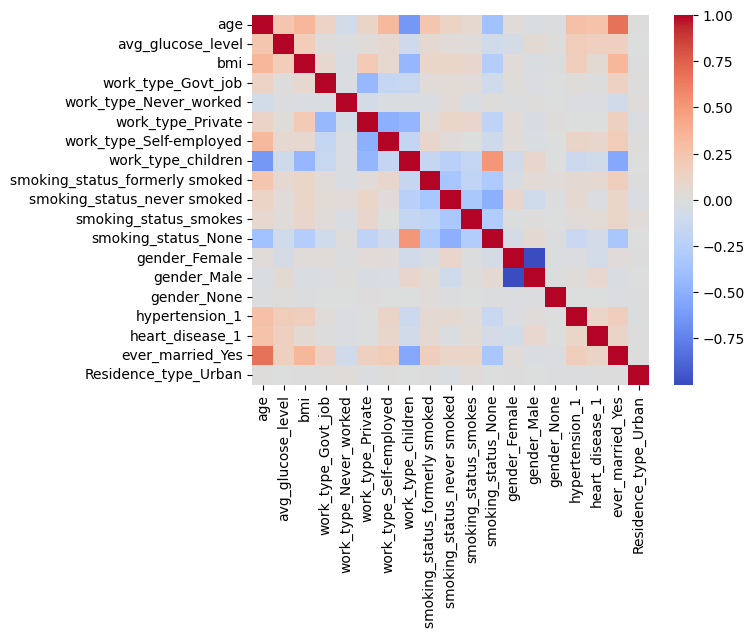

In [282]:
corr_matrix = data_tr_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

In [283]:
import numpy as np

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

alta_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if abs(upper.loc[row, col]) >= 0.8
]

alta_corr

[('gender_Male', 'gender_Female', np.float64(-0.9995967577901111))]

### B1.5 Métodos filtro (ANOVA / Chi2 / Mutual Information)

In [284]:
# B1.5 Selección por métodos filtro
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif

X_final = data_tr_df.copy()
y_final = y.copy()
X_cols = X_final.columns

f_selector = SelectKBest(score_func=f_classif, k="all")
f_selector.fit(data_tr_df, y)

f_scores = pd.Series(f_selector.scores_, index=X_cols).sort_values(ascending=False)

print("Top ANOVA F-test:")
print(f_scores.head(10))

Top ANOVA F-test:
age                               326.916568
heart_disease_1                    94.698406
avg_glucose_level                  90.503870
hypertension_1                     84.953542
ever_married_Yes                   60.667230
work_type_children                 36.184470
smoking_status_formerly smoked     21.376277
work_type_Self-employed            19.818466
smoking_status_None                16.006799
bmi                                13.457355
dtype: float64


In [285]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_final)

chi2_scores, p_values = chi2(X_scaled, y_final)
chi2_scores = pd.Series(chi2_scores, index=X_cols).sort_values(ascending=False)

print("Top Chi2:")
print(chi2_scores.head(10))

Top Chi2:
heart_disease_1                   87.987436
hypertension_1                    75.449498
age                               44.457607
work_type_children                31.111620
ever_married_Yes                  20.622787
smoking_status_formerly smoked    17.607359
work_type_Self-employed           16.584252
avg_glucose_level                 16.500665
smoking_status_None               11.139767
work_type_Never_worked             1.126929
dtype: float64


In [286]:
mi = mutual_info_classif(X_scaled, y_final, random_state=111)
mi_scores = pd.Series(mi, index=X_cols).sort_values(ascending=False)

In [287]:
print("Top Mutual Information:")
print(mi_scores.head(10))

Top Mutual Information:
age                        0.042224
bmi                        0.008601
work_type_Never_worked     0.008518
heart_disease_1            0.006930
ever_married_Yes           0.006763
avg_glucose_level          0.006481
hypertension_1             0.006345
work_type_Self-employed    0.005972
work_type_children         0.005032
gender_Male                0.004068
dtype: float64


In [288]:
rank_df = pd.DataFrame({
    "ANOVA_rank": f_scores.rank(ascending=False),
    "Chi2_rank": chi2_scores.rank(ascending=False),
    "MI_rank": mi_scores.rank(ascending=False)
})

rank_df = rank_df.sort_values("ANOVA_rank")
rank_df.head(15)

,ANOVA_rank,Chi2_rank,MI_rank
age,1.0,3.0,1.0
heart_disease_1,2.0,1.0,4.0
avg_glucose_level,3.0,8.0,6.0
hypertension_1,4.0,2.0,7.0
ever_married_Yes,5.0,5.0,5.0
work_type_children,6.0,4.0,9.0
smoking_status_formerly smoked,7.0,6.0,17.0
work_type_Self-employed,8.0,7.0,8.0
smoking_status_None,9.0,9.0,17.0
bmi,10.0,12.0,2.0


Al comparar los rankings de `ANOVA F-test`, `Chi-cuadrado` y `Mutual Information`, se observa que `age`, `heart_disease_1` y `ever_married_Yes` se mantienen consistentes en el top de las características más importantes en los tres métodos, lo que indica que su relación con los accidentes cerebrovasculares es importante.

In [289]:
rank_df["total_rank"] = rank_df.sum(axis=1)
rank_df["final_rank"] = rank_df["total_rank"].rank(method="min", ascending=True)

rank_df_definitivo = rank_df.sort_values("final_rank")
rank_df_definitivo.head(15)

,ANOVA_rank,Chi2_rank,MI_rank,total_rank,final_rank
age,1.0,3.0,1.0,5.0,1.0
heart_disease_1,2.0,1.0,4.0,7.0,2.0
hypertension_1,4.0,2.0,7.0,13.0,3.0
ever_married_Yes,5.0,5.0,5.0,15.0,4.0
avg_glucose_level,3.0,8.0,6.0,17.0,5.0
work_type_children,6.0,4.0,9.0,19.0,6.0
work_type_Self-employed,8.0,7.0,8.0,23.0,7.0
bmi,10.0,12.0,2.0,24.0,8.0
work_type_Never_worked,12.0,10.0,3.0,25.0,9.0
smoking_status_formerly smoked,7.0,6.0,17.0,30.0,10.0


### B1.6 Conclusiones de selección preliminar
Escribe aquí tus conclusiones sobre:
- Método de imputación elegido.
- Variables que podrían eliminarse por alta correlación.
- Subconjunto preliminar de características relevantes según métodos filtro.


### Método de imputación elegido:
Se seleccionó `IterativeImputer` para las variables numéricas ya que este permite conservar las relaciones entre variables continuas y obtuvo un mayor recall en la predicción de stroke, lo cual es importante en un contexto médico.

### Variables que podrían eliminarse por alta correlación:
Tras analizar la matriz de correlación, se observó que el par de variables `gender_Male - gender_Female` cuenta con una correlación extremadamente alta (0.9996).

Esto es esperado, ya que son características mutuamente excluyentes de la misma variable.

### Subconjunto preliminar de características relevantes según métodos filtro:
Sumando los rankings de ANOVA, Chi2 y Mutual Information y seleccionando las 10 mejores, el subconjunto preliminar incluiría:

1. age
2. heart_disease_1
3. hypertension_1
4. ever_married_Yes
5. avg_glucose_level
6. work_type_children
7. work_type_Self-employed
8. bmi
9. work_type_Never_worked
10. smoking_status_formerly smoked

---
## Pregunta B2 (5 puntos): Selección de características avanzada e impacto en clasificación

**Objetivo:** Aplicar métodos wrapper y embedded para selección de características, y evaluar su impacto en el rendimiento de modelos supervisados.

### Tareas

1. **Métodos wrapper (RFE):**
   - Aplicar `RFE` con Logistic Regression.
   - Aplicar `RFE` con Random Forest.
   - Comparar los subconjuntos de características obtenidos.

2. **Métodos embedded:**
   - Aplicar Lasso (L1) y observar qué coeficientes se aproximan a cero.
   - Calcular importancia de características con Random Forest (`feature_importances_`).

3. **Construcción de un subconjunto final de características:**
   - Proponer un subconjunto final de características combinando la evidencia de filtros, RFE y métodos embedded.
   - Justificar por qué ese subconjunto es razonable.

4. **Evaluación del impacto en modelos de clasificación:**
   - Entrenar Logistic Regression y Random Forest en dos escenarios:
     1. Usando todas las características.
     2. Usando únicamente el subconjunto seleccionado.
   - Evaluar con: Accuracy, F1-score, ROC-AUC (en validación o test).

5. **Análisis final:**
   - Discutir si la selección de características mejora la generalización, la simplicidad del modelo o ambas.
   - Comentar si se observa sobreajuste cuando se usan todas las características.

### Entregables B2

- Comparación de subconjuntos seleccionados por RFE, Lasso y Random Forest.
- Tabla de métricas en los dos escenarios (todas las features vs subconjunto).
- Gráfico de importancia de características (barplot recomendado).
- Conclusión técnica bien argumentada.

**Valoración (5 pts):**  
- Ejecución: 2 pts  
- Análisis e interpretación: 3 pts


### B2.1 RFE con Logistic Regression y Random Forest

In [290]:
# B2.1 Aplicar RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Definir modelos base y aplicar RFE
X_rfe = data_tr_df.copy()
y_rfe = y.copy()
feature_names = X_rfe.columns

In [291]:
lr_model = LogisticRegression(max_iter=5000, random_state=111)
n_features_lr = 10
rfe_lr = RFE(lr_model, n_features_to_select=n_features_lr)
rfe_lr.fit(X_rfe, y_rfe)

selected_lr = X_rfe.columns[rfe_lr.support_]
print("Características seleccionadas por RFE (Logistic Regression):")
print(selected_lr.tolist())

Características seleccionadas por RFE (Logistic Regression):
['age', 'avg_glucose_level', 'work_type_Govt_job', 'work_type_Self-employed', 'work_type_children', 'smoking_status_never smoked', 'smoking_status_smokes', 'hypertension_1', 'heart_disease_1', 'ever_married_Yes']


In [292]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=111)
n_features_rf = 10
rfe_rf = RFE(rf_model, n_features_to_select=n_features_rf)
rfe_rf.fit(X_rfe, y_rfe)

selected_rf = X_rfe.columns[rfe_rf.support_]
print("Características seleccionadas por RFE (Random Forest):")
print(selected_rf.tolist())

Características seleccionadas por RFE (Random Forest):
['age', 'avg_glucose_level', 'bmi', 'work_type_Private', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'gender_Female', 'hypertension_1', 'heart_disease_1', 'Residence_type_Urban']


In [293]:
comunes = set(selected_lr).intersection(set(selected_rf))
print("Características comunes en ambos métodos:")
print(list(comunes))

Características comunes en ambos métodos:
['age', 'avg_glucose_level', 'smoking_status_never smoked', 'heart_disease_1', 'hypertension_1']


Al aplicar RFE con Logistic Regression y Random Forest, se observa que ambos métodos coinciden en un subconjunto de variables importantes:
- heart_disease_1
- age
- avg_glucose_level
- smoking_status_never smoked
- hypertension_1

Indicando que estas características son relevantes tanto para modelos lineales como no lineales.

Por otro lado, cada método selecciona algunas variables específicas adicionales. Logistic Regression prioriza ciertas categorías de trabajo y estado civil, mientras que Random Forest destaca bmi, work_type_Private, gender_Female y Residence_type_Urban.

Teniendo esto en cuenta, podemos utilizar las características comunes como un subconjunto confiable para incluir en los modelos finales.

### B2.2 Métodos embedded (Lasso y Random Forest Importance)

In [294]:
# B2.2 Lasso y Random Forest Importance
from sklearn.linear_model import LassoCV

X_scaled = scaler.fit_transform(data_tr_df)
X_cols = data_tr_df.columns

lasso = LassoCV(max_iter=10000, cv=5, random_state=111).fit(X_scaled, y)
coef = pd.Series(lasso.coef_, index=X_cols)

selected_lasso = coef[coef != 0].sort_values(ascending=False)
print("Características seleccionadas por Lasso (coef != 0):")
print(selected_lasso.index.tolist())

selected_lasso.plot(kind='barh', figsize=(8,5), title="Coeficientes no nulos - Lasso")
plt.xlabel("Coeficiente")
plt.show()

d:\Ciclo VIII\Data Mining Tools\env311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
d:\Ciclo VIII\Data Mining Tools\env311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
d:\Ciclo VIII\Data Mining Tools\env311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increas

Características seleccionadas por Lasso (coef != 0):
[]


d:\Ciclo VIII\Data Mining Tools\env311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
d:\Ciclo VIII\Data Mining Tools\env311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
d:\Ciclo VIII\Data Mining Tools\env311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increas

IndexError: index 0 is out of bounds for axis 0 with size 0

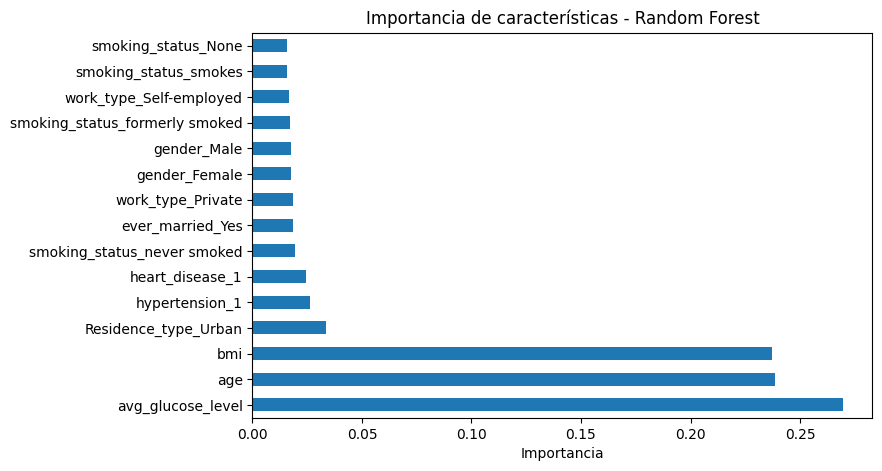

In [ ]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=111)
rf_model.fit(data_tr_df, y)

importances = pd.Series(rf_model.feature_importances_, index=X_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8,5), title="Importancia de características - Random Forest")
plt.xlabel("Importancia")
plt.show()

### B2.3 Definición del subconjunto final de características

El subconjunto preliminar de características propuesto, compuesto por:

1. age
2. heart_disease_1
3. hypertension_1
4. ever_married_Yes
5. avg_glucose_level
6. work_type_children
7. work_type_Self-employed
8. bmi
9. work_type_Never_worked
10. smoking_status_formerly smoked

Se considera razonable ya que todas estas variables han sido identificadas como relevantes por distintos métodos de selección.

### B2.4 Evaluación de modelos con todas las características vs subconjunto

In [ ]:
# B2.4 Entrenar y evaluar Logistic Regression y Random Forest
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

X = data_tr_df.copy()
y = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

def metricas(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }


subconjunto_caracteristicas = ['age', 'heart_disease_1', 'hypertension_1', 'ever_married_Yes', 'avg_glucose_level', 'work_type_children', 'work_type_Self-employed', 'bmi', 'work_type_Never_worked', 'smoking_status_formerly smoked']

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=111),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=111)
}

feature_sets = {
    'Todas las características': X.columns,
    'Subconjunto seleccionado': subconjunto_caracteristicas
}

In [ ]:
resultados = []

for model_name, model in models.items():
    for feature_name, features in feature_sets.items():
        model.fit(X_train[features], y_train)
        y_pred = model.predict(X_test[features])
        y_prob = model.predict_proba(X_test[features])[:, 1]

        m = metricas(y_test, y_pred, y_prob)
        resultados.append({
            'Modelo': model_name,
            'Características': feature_name,
            **m
        })

In [ ]:
df_results = pd.DataFrame(resultados)
df_results = df_results.sort_values(by='Recall', ascending=False)

df_results

,Modelo,Características,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Todas las características,0.951729,1.0,0.013333,0.026316,0.838930
2,Random Forest,Todas las características,0.951076,0.5,0.013333,0.025974,0.804170
1,Logistic Regression,Subconjunto seleccionado,0.951076,0.0,0.000000,0.000000,0.840293
3,Random Forest,Subconjunto seleccionado,0.949772,0.0,0.000000,0.000000,0.810133


A partir de los resultados obtenidos, se observa que en este caso, la reducción al subconjunto seleccionado de 10 características no mejora significativamente las métricas de desempeño en términos de recall y F1-score, las cuales siguen siendo extremadamente bajas en ambos modelos.

Por lo que, si bien la selección de características aporta simplicidad y menor dimensionalidad en muchos casos, por lo menos en este caso y con este subconjunto de características seleccionadas, la reducción de características no genera una mejora notable en la generalización probablemente por una mala elección del subconjunto.

### B2.5 Conclusiones finales de la práctica
Escribe aquí tus conclusiones generales sobre:
- El efecto del preprocesamiento y la imputación.
- Las diferencias entre los algoritmos de clustering.
- La importancia de la selección de características en modelos supervisados.


El preprocesamiento, la imputación de valores faltantes mediante IterativeImputer y SimpleImputer, el One Hot Encoding y escalado, nos permitieron mantener la estructura de los datos y facilitar la aplicación de modelos supervisados.

Con respecto al clustering, K-Means y Clustering Jerárquico mostraron clusters relativamente bien separados y compactos, siendo más interpretables que Gaussian Mixture, mientras que DBSCAN no logró formar clusters válidos, evidenciando su sensibilidad al ruido y la densidad de los datos.

La selección de características con métodos filtro, wrapper y embedded permitió identificar un subconjunto de 10 variables relevantes, combinando importancia estadística y relevancia clínica. Aunque se redujo la complejidad del modelo y mejoró la interpretabilidad, no se aumentó significativamente la capacidad predictiva debido al desbalance de la variable objetivo.

En conclusión, los resultados confirman que un preprocesamiento adecuado y una selección de características adecuada son importantes para construir modelos interpretables, aunque la efectividad final también depende de la naturaleza y distribución de los datos.

---
# RÚBRICA GLOBAL – 20 puntos

| Parte | Pregunta | Ejecución (2 pts) | Análisis (3 pts) | Total |
|------|-----------|------------------|------------------|--------|
| A    | A1        | 2                | 3                | 5      |
| A    | A2        | 2                | 3                | 5      |
| B    | B1        | 2                | 3                | 5      |
| B    | B2        | 2                | 3                | 5      |

**Nota:** La calidad de las conclusiones, la claridad de los gráficos y la correcta justificación de las decisiones metodológicas tendrán un peso importante dentro de la sección de análisis.
